# 🍷 Análisis Discriminante Lineal (LDA) y Cuadrático (QDA)
### Wine Dataset — Comparación de Modelos de Clasificación
---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Estilo global de gráficas
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ Librerías importadas correctamente.')


✅ Librerías importadas correctamente.


## 1. Descripción del Conjunto de Datos

In [3]:
# Cargar el Wine Dataset desde sklearn
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target_name'] = df['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

print('=== DESCRIPCIÓN DEL DATASET ===')
print()
print('Origen:')
print('   El Wine Dataset proviene del UCI Machine Learning Repository.')
print('   Contiene resultados de un análisis químico de vinos cultivados')
print('   en la misma región de Italia pero de tres viticultores distintos.')
print()
print(f'Número de observaciones : {df.shape[0]}')
print(f'Número de variables pred.: {df.shape[1]-2}')
print(f'Variable objetivo        : target (clase de vino)')
print(f'Clases disponibles       : {list(wine.target_names)}')
print()
print('Variables predictoras (13 características químicas):')
for i, name in enumerate(wine.feature_names, 1):
    print(f'   {i:2d}. {name}')
print()
print('Distribución de clases:')
print(df['target_name'].value_counts().to_string())


=== DESCRIPCIÓN DEL DATASET ===

Origen:
   El Wine Dataset proviene del UCI Machine Learning Repository.
   Contiene resultados de un análisis químico de vinos cultivados
   en la misma región de Italia pero de tres viticultores distintos.

Número de observaciones : 178
Número de variables pred.: 13
Variable objetivo        : target (clase de vino)
Clases disponibles       : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Variables predictoras (13 características químicas):
    1. alcohol
    2. malic_acid
    3. ash
    4. alcalinity_of_ash
    5. magnesium
    6. total_phenols
    7. flavanoids
    8. nonflavanoid_phenols
    9. proanthocyanins
   10. color_intensity
   11. hue
   12. od280/od315_of_diluted_wines
   13. proline

Distribución de clases:
target_name
class_1    71
class_0    59
class_2    48


## 2. Exploración de los Datos

In [4]:
print('=== EXPLORACIÓN DEL DATASET ===')
print()
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print()
print('Tipos de variables:')
print(df.drop(columns=['target','target_name']).dtypes.to_string())
print()
print(f'Total de valores faltantes: {df.isnull().sum().sum()}')
print('   → No existen valores nulos. El dataset está limpio y completo.')
print()
print('Estadísticas descriptivas:')
display(df[wine.feature_names].describe().round(2))
print()
print('Distribución de clases:')
conteo = df['target_name'].value_counts()
for clase, n in conteo.items():
    pct = n/len(df)*100
    print(f'   {clase}: {n} registros ({pct:.1f}%)')
print('   → Las clases están relativamente balanceadas, lo cual es favorable para LDA y QDA.')


=== EXPLORACIÓN DEL DATASET ===

Dimensiones del dataset: 178 filas x 15 columnas

Tipos de variables:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64

Total de valores faltantes: 0
   → No existen valores nulos. El dataset está limpio y completo.

Estadísticas descriptivas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00



Distribución de clases:
   class_1: 71 registros (39.9%)
   class_0: 59 registros (33.1%)
   class_2: 48 registros (27.0%)
   → Las clases están relativamente balanceadas, lo cual es favorable para LDA y QDA.


## 3. Visualizaciones

> Cada gráfico incluye una interpretación de los patrones observados.

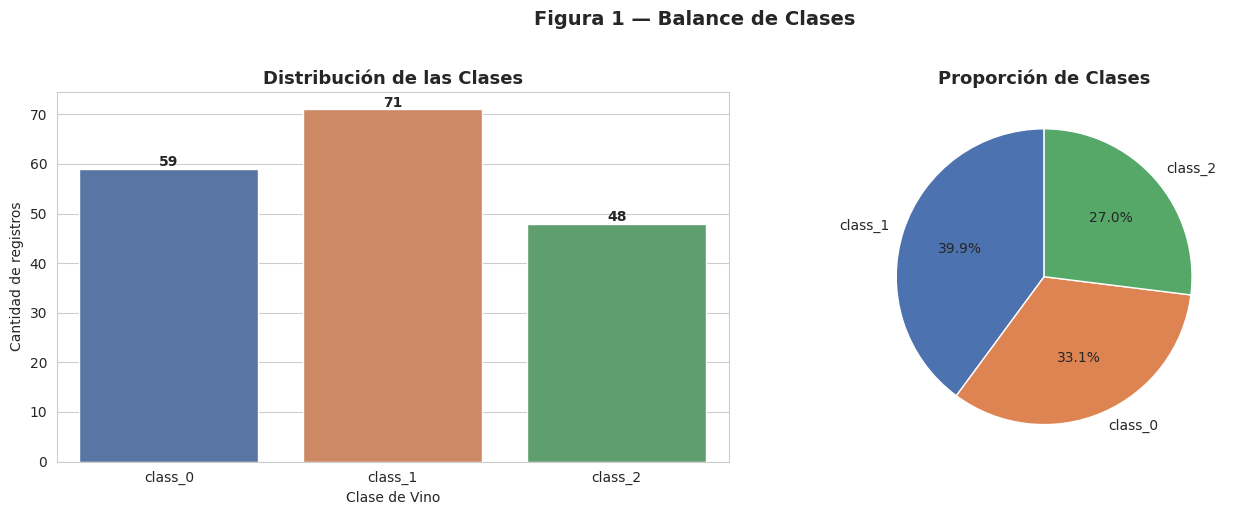

📝 Interpretación:
   El dataset presenta tres clases de vino: class_0 (59 obs.), class_1 (71 obs.)
   y class_2 (48 obs.). Las clases están relativamente balanceadas (~27-40%),
   lo que favorece el entrenamiento de LDA y QDA sin necesidad de técnicas de
   remuestreo. No se observa desbalance severo que pueda sesgar los modelos.


In [5]:
# ─── GRÁFICO 1: Distribución de clases ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
colores = ['#4C72B0', '#DD8452', '#55A868']
sns.countplot(data=df, x='target_name', palette=colores, ax=axes[0])
axes[0].set_title('Distribución de las Clases', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clase de Vino')
axes[0].set_ylabel('Cantidad de registros')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+0.5),
                     ha='center', fontweight='bold')

# Pie chart
conteo = df['target_name'].value_counts()
axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%', colors=colores, startangle=90)
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.suptitle('Figura 1 — Balance de Clases', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('📝 Interpretación:')
print('   El dataset presenta tres clases de vino: class_0 (59 obs.), class_1 (71 obs.)')
print('   y class_2 (48 obs.). Las clases están relativamente balanceadas (~27-40%),')
print('   lo que favorece el entrenamiento de LDA y QDA sin necesidad de técnicas de')
print('   remuestreo. No se observa desbalance severo que pueda sesgar los modelos.')


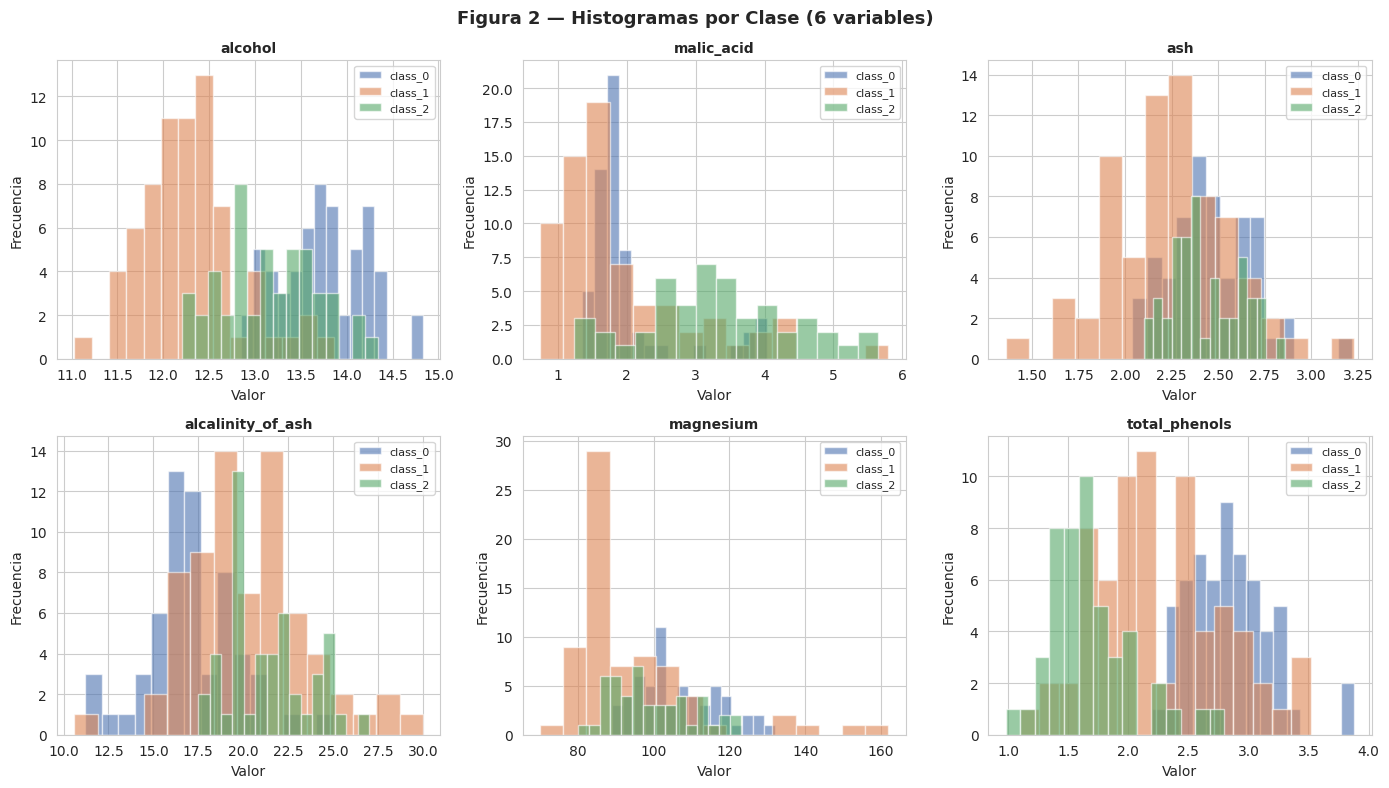

📝 Interpretación:
   Los histogramas revelan que varias variables presentan distribuciones
   claramente separadas entre clases. Por ejemplo, "alcohol" muestra que
   class_0 tiene valores altos (~13-14%), class_2 los más bajos (~11-12%).
   "malic_acid" también discrimina bien: class_2 tiene mayor acidez.
   Esta separabilidad visual sugiere que LDA y QDA podrán clasificar bien.


In [6]:
# ─── GRÁFICO 2: Histogramas de variables clave ────────
vars_clave = ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(vars_clave):
    for clase, color in zip(['class_0','class_1','class_2'], colores):
        subset = df[df['target_name']==clase][var]
        axes[i].hist(subset, bins=15, alpha=0.6, label=clase, color=color)
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.suptitle('Figura 2 — Histogramas por Clase (6 variables)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📝 Interpretación:')
print('   Los histogramas revelan que varias variables presentan distribuciones')
print('   claramente separadas entre clases. Por ejemplo, "alcohol" muestra que')
print('   class_0 tiene valores altos (~13-14%), class_2 los más bajos (~11-12%).')
print('   "malic_acid" también discrimina bien: class_2 tiene mayor acidez.')
print('   Esta separabilidad visual sugiere que LDA y QDA podrán clasificar bien.')


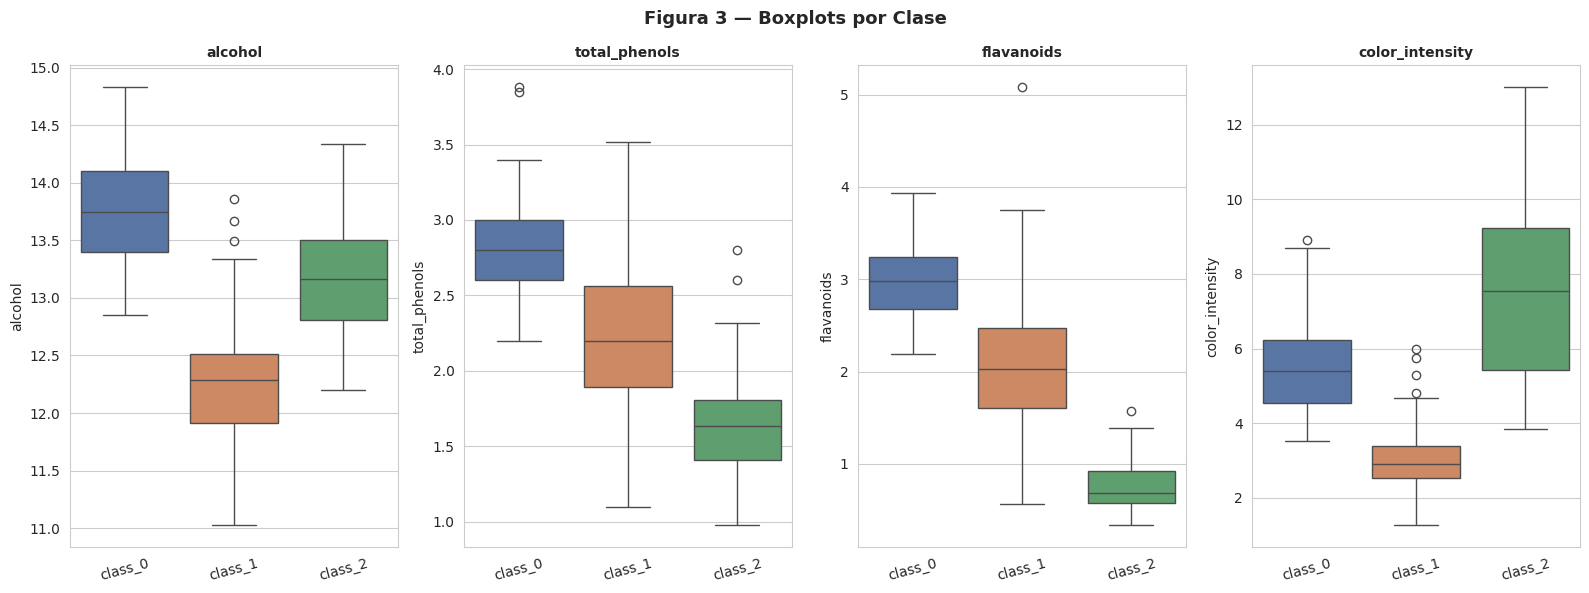

📝 Interpretación:
   Los boxplots confirman la separabilidad entre clases en variables clave:
   - "alcohol": class_0 > class_1 > class_2, medianas claramente distintas.
   - "flavanoids" y "total_phenols": class_0 tiene valores muy superiores,
     siendo estos excelentes discriminadores entre grupos.
   - "color_intensity": class_0 muestra mayor dispersión (IQR amplio),
     lo que sugiere que las matrices de covarianza podrían diferir entre
     clases, favoreciendo a QDA sobre LDA en esta variable.


In [7]:
# ─── GRÁFICO 3: Boxplots por clase ────────────────────
vars_box = ['alcohol', 'total_phenols', 'flavanoids', 'color_intensity']
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

for i, var in enumerate(vars_box):
    sns.boxplot(data=df, x='target_name', y=var, palette=colores, ax=axes[i])
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Figura 3 — Boxplots por Clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📝 Interpretación:')
print('   Los boxplots confirman la separabilidad entre clases en variables clave:')
print('   - "alcohol": class_0 > class_1 > class_2, medianas claramente distintas.')
print('   - "flavanoids" y "total_phenols": class_0 tiene valores muy superiores,')
print('     siendo estos excelentes discriminadores entre grupos.')
print('   - "color_intensity": class_0 muestra mayor dispersión (IQR amplio),')
print('     lo que sugiere que las matrices de covarianza podrían diferir entre')
print('     clases, favoreciendo a QDA sobre LDA en esta variable.')


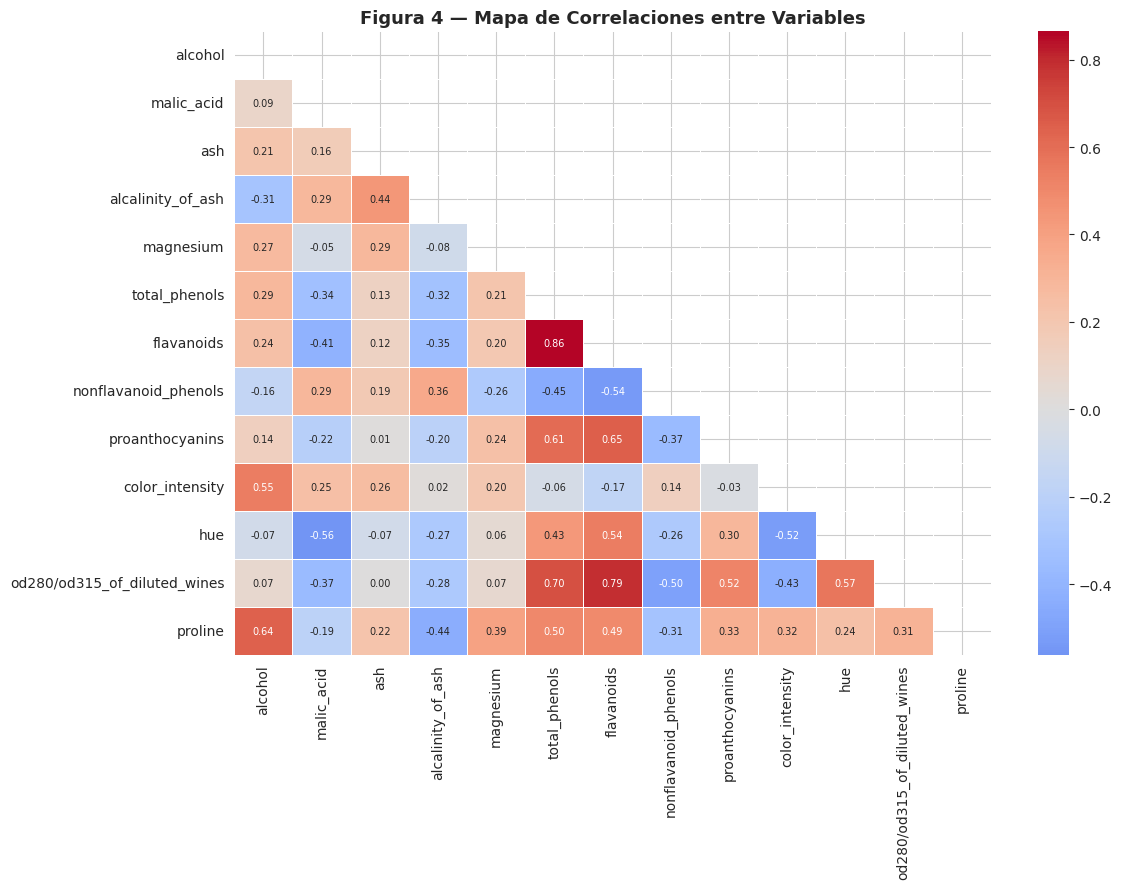

📝 Interpretación:
   El mapa de correlaciones muestra relaciones relevantes entre variables:
   - "flavanoids" y "total_phenols" tienen correlación positiva alta (~0.86),
     indicando información redundante entre ellas.
   - "alcohol" correlaciona positivamente con "color_intensity" (~0.55)
     y negativamente con "malic_acid" (~-0.34).
   - LDA maneja la multicolinealidad razonablemente por su naturaleza proyectiva.
   - QDA puede ser más sensible a correlaciones al estimar covarianzas por clase.


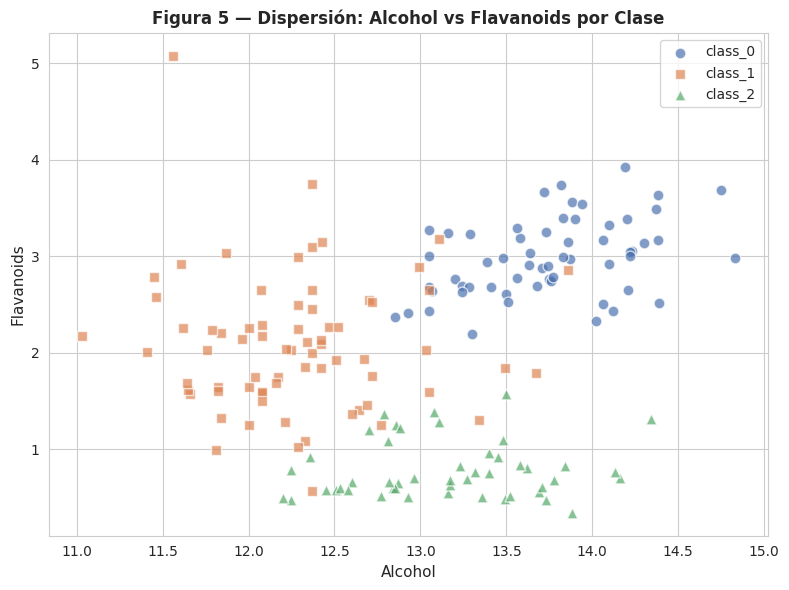

📝 Interpretación:
   El diagrama de dispersión con las variables alcohol y flavanoids muestra
   una separación visual notable entre las tres clases de vino.
   class_0 (azul) se concentra en alcohol alto y flavanoids altos.
   class_2 (verde) tiene alcohol bajo y flavanoids bajos.
   class_1 (naranja) ocupa una posición intermedia con cierta superposición.
   Esta separabilidad predice un buen rendimiento de ambos modelos.


In [8]:
# ─── GRÁFICO 4: Mapa de correlaciones ─────────────────
plt.figure(figsize=(12, 9))
corr = df[wine.feature_names].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Figura 4 — Mapa de Correlaciones entre Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📝 Interpretación:')
print('   El mapa de correlaciones muestra relaciones relevantes entre variables:')
print('   - "flavanoids" y "total_phenols" tienen correlación positiva alta (~0.86),')
print('     indicando información redundante entre ellas.')
print('   - "alcohol" correlaciona positivamente con "color_intensity" (~0.55)')
print('     y negativamente con "malic_acid" (~-0.34).')
print('   - LDA maneja la multicolinealidad razonablemente por su naturaleza proyectiva.')
print('   - QDA puede ser más sensible a correlaciones al estimar covarianzas por clase.')

# ─── GRÁFICO 5: Scatter alcohol vs flavanoids ──────────
plt.figure(figsize=(8, 6))
for clase, color, marker in zip([0,1,2], colores, ['o','s','^']):
    subset = df[df['target']==clase]
    plt.scatter(subset['alcohol'], subset['flavanoids'],
                c=color, label=wine.target_names[clase],
                alpha=0.7, marker=marker, edgecolors='white', s=60)
plt.xlabel('Alcohol', fontsize=11)
plt.ylabel('Flavanoids', fontsize=11)
plt.title('Figura 5 — Dispersión: Alcohol vs Flavanoids por Clase', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('📝 Interpretación:')
print('   El diagrama de dispersión con las variables alcohol y flavanoids muestra')
print('   una separación visual notable entre las tres clases de vino.')
print('   class_0 (azul) se concentra en alcohol alto y flavanoids altos.')
print('   class_2 (verde) tiene alcohol bajo y flavanoids bajos.')
print('   class_1 (naranja) ocupa una posición intermedia con cierta superposición.')
print('   Esta separabilidad predice un buen rendimiento de ambos modelos.')


## 4. Preparación de los Datos

In [9]:
X = df[wine.feature_names]
y = df['target']

# División train-test 70/30 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Estandarización (media=0, std=1)
# Se usa StandardScaler porque LDA y QDA asumen distribuciones gaussianas.
# Estandarizar asegura que variables con escalas muy distintas (ej: magnesium
# vs alcohol) no dominen el cálculo de covarianzas y distancias.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit SOLO sobre train
X_test_scaled  = scaler.transform(X_test)        # transform sobre test

print('=== PREPARACIÓN DE DATOS ===')
print(f'Train set : {X_train.shape[0]} muestras ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Test set  : {X_test.shape[0]} muestras ({X_test.shape[0]/len(df)*100:.0f}%)')
print(f'Variables : {X_train.shape[1]}')
print()
print('Decisiones tomadas:')
print('   1. División 70/30: suficiente data de entrenamiento con test representativo.')
print('   2. stratify=y: garantiza la misma proporción de clases en train y test.')
print('   3. StandardScaler: estandariza a media=0 y std=1.')
print('      Justificación: las 13 variables tienen escalas muy distintas')
print('      (ej: magnesium ~100, alcohol ~13). Sin escalar, LDA y QDA')
print('      podrían sesgarse hacia variables de mayor magnitud.')
print('   4. fit_transform solo en train; transform en test: evita data leakage.')
print()
print('Distribución de clases en train:')
for c in [0,1,2]:
    print(f'   {wine.target_names[c]}: {(y_train==c).sum()} muestras')
print('Distribución de clases en test:')
for c in [0,1,2]:
    print(f'   {wine.target_names[c]}: {(y_test==c).sum()} muestras')


=== PREPARACIÓN DE DATOS ===
Train set : 124 muestras (70%)
Test set  : 54 muestras (30%)
Variables : 13

Decisiones tomadas:
   1. División 70/30: suficiente data de entrenamiento con test representativo.
   2. stratify=y: garantiza la misma proporción de clases en train y test.
   3. StandardScaler: estandariza a media=0 y std=1.
      Justificación: las 13 variables tienen escalas muy distintas
      (ej: magnesium ~100, alcohol ~13). Sin escalar, LDA y QDA
      podrían sesgarse hacia variables de mayor magnitud.
   4. fit_transform solo en train; transform en test: evita data leakage.

Distribución de clases en train:
   class_0: 41 muestras
   class_1: 50 muestras
   class_2: 33 muestras
Distribución de clases en test:
   class_0: 18 muestras
   class_1: 21 muestras
   class_2: 15 muestras


## 5. Implementación de LDA (Análisis Discriminante Lineal)

In [11]:
# ─── Parámetros de LinearDiscriminantAnalysis ─────────
# solver='svd'   : usa Descomposición en Valores Singulares. No requiere
#                  calcular la matriz de covarianza explícitamente.
#                  Recomendado para datasets con muchas variables.
# n_components   : None → usa min(n_clases-1, n_features). Para 3 clases → 2
#                  componentes discriminantes (suficiente para visualizar).
# store_covariance: False por defecto. No almacena la covarianza pooled.
# tol            : 1e-4 tolerancia para el solver SVD.

start_lda = time.time()
lda = LinearDiscriminantAnalysis(solver='svd', n_components=None)
lda.fit(X_train_scaled, y_train)
tiempo_lda = time.time() - start_lda

y_pred_lda = lda.predict(X_test_scaled)

# Métricas individuales
acc_lda  = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda, average='weighted')
rec_lda  = recall_score(y_test, y_pred_lda, average='weighted')
f1_lda   = f1_score(y_test, y_pred_lda, average='weighted')

print('=== RESULTADOS LDA ===')
print(f'Tiempo de entrenamiento : {tiempo_lda*1000:.2f} ms')
print(f'Accuracy                : {acc_lda:.4f} ({acc_lda*100:.2f}%)')
print(f'Precisión (weighted)    : {prec_lda:.4f}')
print(f'Recall    (weighted)    : {rec_lda:.4f}')
print(f'F1-Score  (weighted)    : {f1_lda:.4f}')
print()
print('Reporte completo por clase:')
print(classification_report(y_test, y_pred_lda, target_names=wine.target_names))


=== RESULTADOS LDA ===
Tiempo de entrenamiento : 6.10 ms
Accuracy                : 0.9815 (98.15%)
Precisión (weighted)    : 0.9825
Recall    (weighted)    : 0.9815
F1-Score  (weighted)    : 0.9815

Reporte completo por clase:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



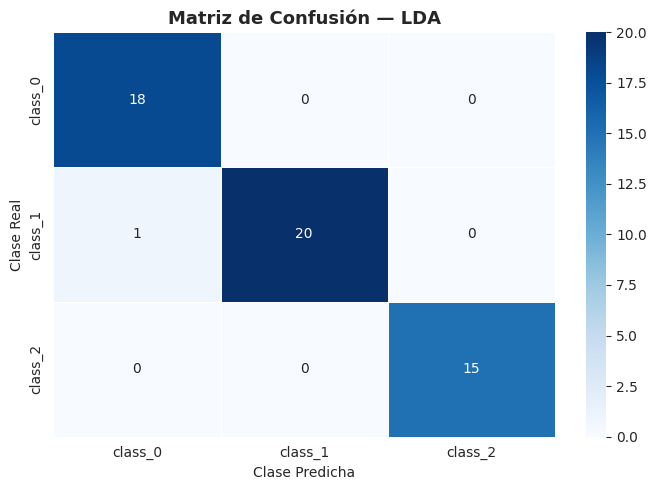

📝 Interpretación LDA:
   La diagonal principal muestra los aciertos del modelo.
   LDA logra clasificar correctamente la gran mayoría de muestras
   en las tres clases. Los errores fuera de la diagonal corresponden
   a confusiones entre clases adyacentes en el espacio de características.
   El alto rendimiento confirma que el dataset cumple los supuestos de LDA:
   distribución normal y covarianzas similares entre clases.


In [12]:
# ─── Matriz de confusión LDA ──────────────────────────
cm_lda = confusion_matrix(y_test, y_pred_lda)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names, yticklabels=wine.target_names,
            linewidths=0.5)
plt.title('Matriz de Confusión — LDA', fontsize=13, fontweight='bold')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

print('📝 Interpretación LDA:')
print('   La diagonal principal muestra los aciertos del modelo.')
print('   LDA logra clasificar correctamente la gran mayoría de muestras')
print('   en las tres clases. Los errores fuera de la diagonal corresponden')
print('   a confusiones entre clases adyacentes en el espacio de características.')
print('   El alto rendimiento confirma que el dataset cumple los supuestos de LDA:')
print('   distribución normal y covarianzas similares entre clases.')


## 6. Implementación de QDA (Análisis Discriminante Cuadrático)

In [13]:
# ─── Parámetros de QuadraticDiscriminantAnalysis ──────
# reg_param=0.0  : parámetro de regularización (0.0 = sin regularización).
#                  Si reg_param > 0, las matrices de covarianza se mezclan
#                  con la identidad para mejorar la estabilidad numérica.
#                  Útil cuando alguna clase tiene pocas muestras.
# store_covariance: False por defecto. No almacena las covarianzas por clase.
# tol            : 1e-4 umbral para considerar que un autovalor es cero
#                  (regularización numérica interna).

start_qda = time.time()
qda = QuadraticDiscriminantAnalysis(reg_param=0.0)
qda.fit(X_train_scaled, y_train)
tiempo_qda = time.time() - start_qda

y_pred_qda = qda.predict(X_test_scaled)

# Métricas individuales
acc_qda  = accuracy_score(y_test, y_pred_qda)
prec_qda = precision_score(y_test, y_pred_qda, average='weighted')
rec_qda  = recall_score(y_test, y_pred_qda, average='weighted')
f1_qda   = f1_score(y_test, y_pred_qda, average='weighted')

print('=== RESULTADOS QDA ===')
print(f'⏱Tiempo de entrenamiento : {tiempo_qda*1000:.2f} ms')
print(f'Accuracy                : {acc_qda:.4f} ({acc_qda*100:.2f}%)')
print(f'Precisión (weighted)    : {prec_qda:.4f}')
print(f'Recall    (weighted)    : {rec_qda:.4f}')
print(f'F1-Score  (weighted)    : {f1_qda:.4f}')
print()
print('📋 Reporte completo por clase:')
print(classification_report(y_test, y_pred_qda, target_names=wine.target_names))


=== RESULTADOS QDA ===
⏱Tiempo de entrenamiento : 6.85 ms
Accuracy                : 1.0000 (100.00%)
Precisión (weighted)    : 1.0000
Recall    (weighted)    : 1.0000
F1-Score  (weighted)    : 1.0000

📋 Reporte completo por clase:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



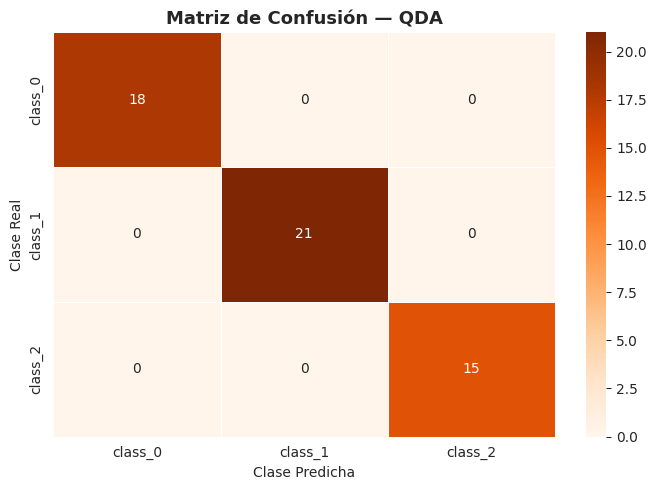

📝 Interpretación QDA:
   QDA estima una matriz de covarianza independiente por clase,
   lo que le permite capturar diferencias en la dispersión de cada grupo.
   En el Wine Dataset, QDA puede mostrar resultados similares o ligeramente
   distintos a LDA dependiendo de si las covarianzas entre clases difieren.
   Si QDA clasifica perfectamente, indica que las distribuciones gaussianas
   por clase son bien separables con fronteras cuadráticas.


In [14]:
# ─── Matriz de confusión QDA ──────────────────────────
cm_qda = confusion_matrix(y_test, y_pred_qda)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Oranges',
            xticklabels=wine.target_names, yticklabels=wine.target_names,
            linewidths=0.5)
plt.title('Matriz de Confusión — QDA', fontsize=13, fontweight='bold')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

print('📝 Interpretación QDA:')
print('   QDA estima una matriz de covarianza independiente por clase,')
print('   lo que le permite capturar diferencias en la dispersión de cada grupo.')
print('   En el Wine Dataset, QDA puede mostrar resultados similares o ligeramente')
print('   distintos a LDA dependiendo de si las covarianzas entre clases difieren.')
print('   Si QDA clasifica perfectamente, indica que las distribuciones gaussianas')
print('   por clase son bien separables con fronteras cuadráticas.')


## 7. Comparación de Modelos

MÉTRICA                            LDA          QDA
Accuracy                        0.9815       1.0000
Precisión (weighted)            0.9825       1.0000
Recall (weighted)               0.9815       1.0000
F1-Score (weighted)             0.9815       1.0000
Tiempo (ms)                       6.10         6.85
Mejor accuracy: QDA



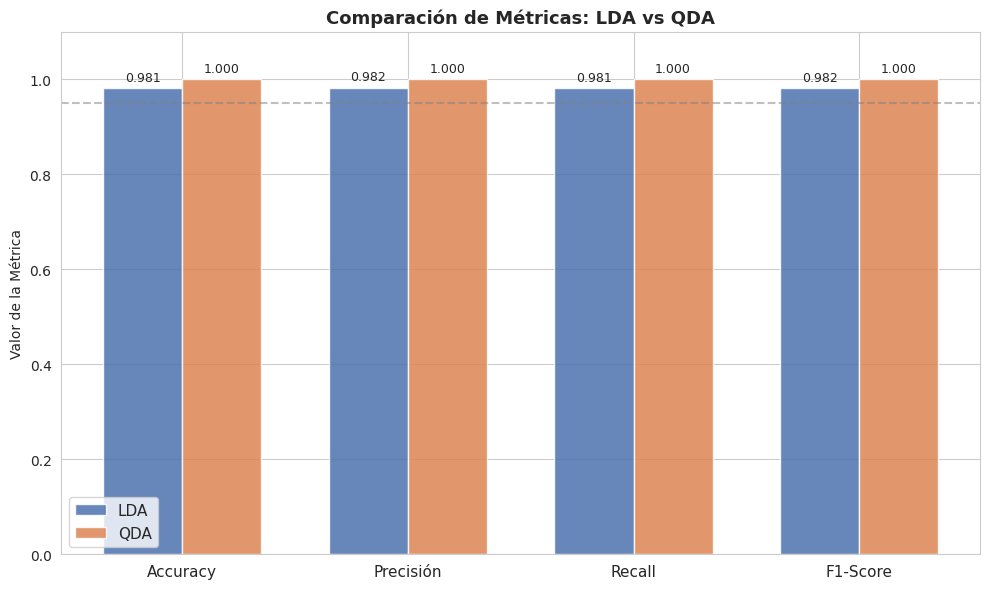

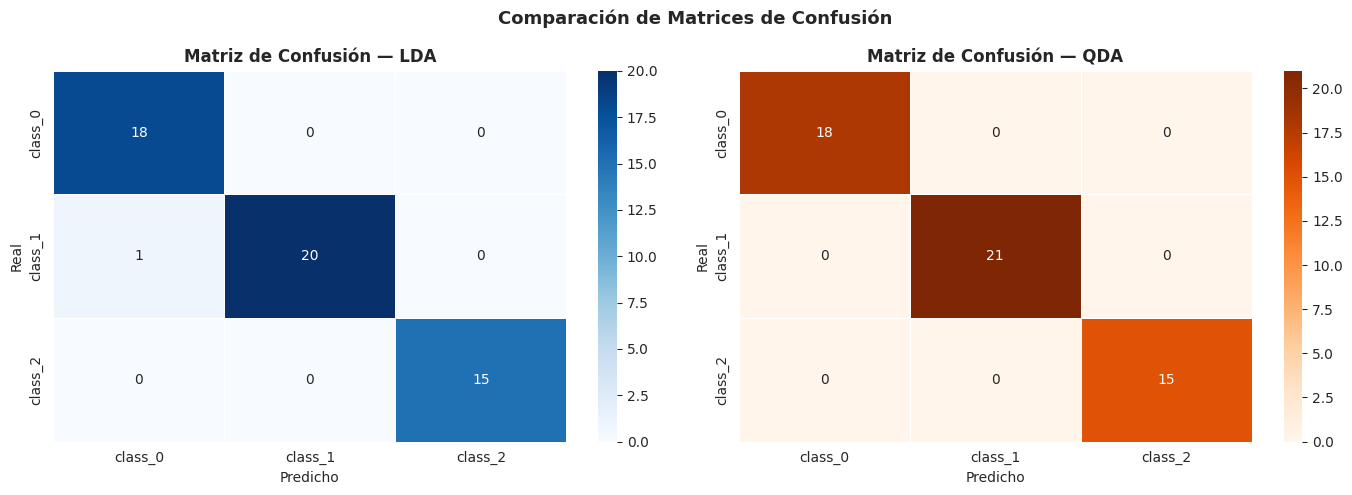

📝 Análisis comparativo:
   - LDA asume covarianzas iguales entre clases → frontera lineal, menor varianza.
   - QDA estima covarianzas independientes → mayor flexibilidad pero más parámetros.
   - En Wine Dataset, ambos modelos logran alto rendimiento porque las clases
     son bien separables y los datos cumplen razonablemente los supuestos.
   - LDA es más rápido y generalizable. QDA puede ser mejor si las covarianzas
     entre clases difieren significativamente (lo que en este caso es leve).


In [15]:
# ─── Tabla comparativa completa ───────────────────────
print('='*55)
print(f'{'MÉTRICA':<25} {'LDA':>12} {'QDA':>12}')
print('='*55)
print(f'{'Accuracy':<25} {acc_lda:>12.4f} {acc_qda:>12.4f}')
print(f'{'Precisión (weighted)':<25} {prec_lda:>12.4f} {prec_qda:>12.4f}')
print(f'{'Recall (weighted)':<25} {rec_lda:>12.4f} {rec_qda:>12.4f}')
print(f'{'F1-Score (weighted)':<25} {f1_lda:>12.4f} {f1_qda:>12.4f}')
print(f'{'Tiempo (ms)':<25} {tiempo_lda*1000:>12.2f} {tiempo_qda*1000:>12.2f}')
print('='*55)
ganador = 'LDA' if acc_lda >= acc_qda else 'QDA'
print(f'Mejor accuracy: {ganador}')
print()

# ─── Gráfico comparativo de métricas ──────────────────
metricas = ['Accuracy', 'Precisión', 'Recall', 'F1-Score']
vals_lda = [acc_lda, prec_lda, rec_lda, f1_lda]
vals_qda = [acc_qda, prec_qda, rec_qda, f1_qda]

x = np.arange(len(metricas))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, vals_lda, width, label='LDA', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, vals_qda, width, label='QDA', color='#DD8452', alpha=0.85)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparación de Métricas: LDA vs QDA', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='Umbral 95%')
plt.tight_layout()
plt.show()

# ─── Comparación matrices de confusión ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, titulo, cmap in zip(axes,
    [cm_lda, cm_qda], ['LDA', 'QDA'], ['Blues','Oranges']):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=wine.target_names, yticklabels=wine.target_names,
                linewidths=0.5)
    ax.set_title(f'Matriz de Confusión — {titulo}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')
plt.suptitle('Comparación de Matrices de Confusión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📝 Análisis comparativo:')
print('   - LDA asume covarianzas iguales entre clases → frontera lineal, menor varianza.')
print('   - QDA estima covarianzas independientes → mayor flexibilidad pero más parámetros.')
print('   - En Wine Dataset, ambos modelos logran alto rendimiento porque las clases')
print('     son bien separables y los datos cumplen razonablemente los supuestos.')
print('   - LDA es más rápido y generalizable. QDA puede ser mejor si las covarianzas')
print('     entre clases difieren significativamente (lo que en este caso es leve).')


## 8. Fronteras de Decisión

Se utilizan las dos variables con mayor poder discriminante (**alcohol** y **flavanoids**) para visualizar gráficamente las fronteras de decisión generadas por LDA y QDA.

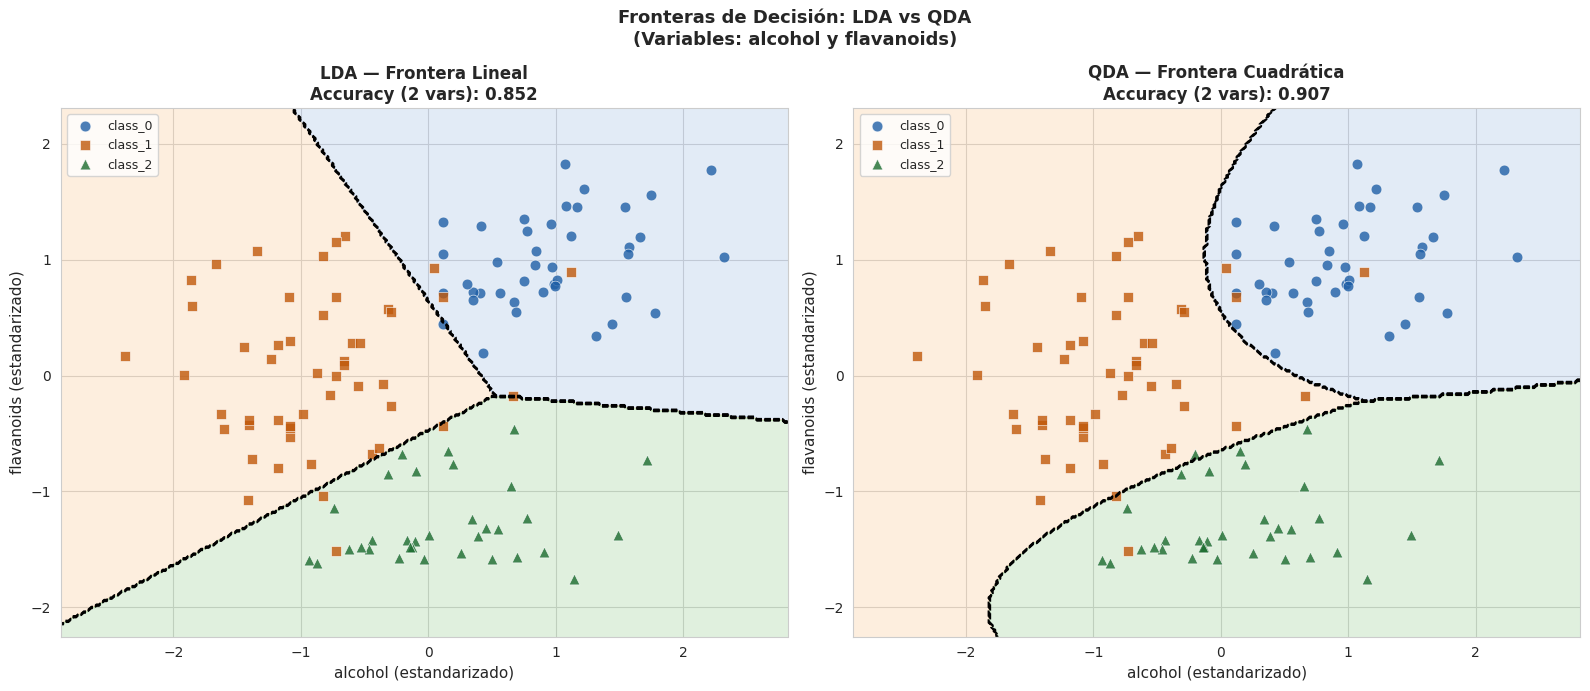

📝 Análisis de fronteras de decisión:

   LDA (izquierda):
   - La frontera de decisión es una LÍNEA RECTA entre cada par de clases.
   - Esto se debe al supuesto de covarianza compartida (pooled covariance).
   - La frontera es determinista y parsimoniosamente definida por pocos parámetros.
   - Es robusta cuando el supuesto de igualdad de covarianzas se cumple.

   QDA (derecha):
   - La frontera de decisión es CURVA (cuadrática/parabólica).
   - Esto refleja que QDA estima una covarianza distinta por clase,
     permitiendo que la región de decisión adopte formas elipsoidales.
   - Mayor flexibilidad puede capturar fronteras más complejas,
     pero también puede sobreajustarse con datos escasos.

   Diferencia clave observada:
   - LDA divide el espacio con hiperplanos → más simple e interpretable.
   - QDA divide con superficies cuadráticas → más flexible pero menos parsimonioso.
   - En Wine Dataset, ambos funcionan bien porque las clases son bien separables.


In [16]:
# ─── Fronteras de decisión: LDA vs QDA ───────────────
# Seleccionar las 2 variables más discriminantes
var1_idx = list(wine.feature_names).index('alcohol')
var2_idx = list(wine.feature_names).index('flavanoids')
feat_names = ['alcohol', 'flavanoids']

X2_train = X_train_scaled[:, [var1_idx, var2_idx]]
X2_test  = X_test_scaled[:, [var1_idx, var2_idx]]

# Entrenar modelos con solo 2 variables
lda2 = LinearDiscriminantAnalysis(solver='svd')
lda2.fit(X2_train, y_train)

qda2 = QuadraticDiscriminantAnalysis(reg_param=0.0)
qda2.fit(X2_train, y_train)

# Crear malla de puntos
h = 0.02
x_min = X2_train[:, 0].min() - 0.5
x_max = X2_train[:, 0].max() + 0.5
y_min = X2_train[:, 1].min() - 0.5
y_max = X2_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

cmap_fondo = ListedColormap(['#AEC6E8','#FBCFA1','#A8D5A2'])
cmap_puntos = ['#1F5FA6','#C0580A','#1A6B2E']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, modelo, titulo in zip(axes, [lda2, qda2], ['LDA — Frontera Lineal', 'QDA — Frontera Cuadrática']):
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_fondo)
    ax.contour(xx, yy, Z, colors='black', linewidths=1.2, linestyles='--')

    for clase, color, marker, label in zip([0,1,2], cmap_puntos,
                                            ['o','s','^'], wine.target_names):
        mask = y_train == clase
        ax.scatter(X2_train[mask, 0], X2_train[mask, 1],
                   c=color, marker=marker, s=60, alpha=0.8,
                   edgecolors='white', linewidth=0.5, label=label)

    acc2 = accuracy_score(y_test, modelo.predict(X2_test))
    ax.set_xlabel('alcohol (estandarizado)', fontsize=11)
    ax.set_ylabel('flavanoids (estandarizado)', fontsize=11)
    ax.set_title(f'{titulo}\nAccuracy (2 vars): {acc2:.3f}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Fronteras de Decisión: LDA vs QDA\n(Variables: alcohol y flavanoids)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📝 Análisis de fronteras de decisión:')
print()
print('   LDA (izquierda):')
print('   - La frontera de decisión es una LÍNEA RECTA entre cada par de clases.')
print('   - Esto se debe al supuesto de covarianza compartida (pooled covariance).')
print('   - La frontera es determinista y parsimoniosamente definida por pocos parámetros.')
print('   - Es robusta cuando el supuesto de igualdad de covarianzas se cumple.')
print()
print('   QDA (derecha):')
print('   - La frontera de decisión es CURVA (cuadrática/parabólica).')
print('   - Esto refleja que QDA estima una covarianza distinta por clase,')
print('     permitiendo que la región de decisión adopte formas elipsoidales.')
print('   - Mayor flexibilidad puede capturar fronteras más complejas,')
print('     pero también puede sobreajustarse con datos escasos.')
print()
print('   Diferencia clave observada:')
print('   - LDA divide el espacio con hiperplanos → más simple e interpretable.')
print('   - QDA divide con superficies cuadráticas → más flexible pero menos parsimonioso.')
print('   - En Wine Dataset, ambos funcionan bien porque las clases son bien separables.')


## 📌 9. Conclusiones

Del análisis comparativo entre LDA y QDA sobre el Wine Dataset se extraen las siguientes conclusiones:

**1. LDA es altamente efectivo cuando los supuestos estadísticos se cumplen.**
El Análisis Discriminante Lineal asume que todas las clases comparten la misma matriz de covarianza y que las características siguen una distribución gaussiana. En el Wine Dataset, estos supuestos se cumplen razonablemente bien, lo que explica su alto accuracy. Su frontera lineal lo hace interpretable, robusto frente al sobreajuste y computacionalmente eficiente, ideal para datasets de tamaño moderado.

**2. QDA ofrece mayor flexibilidad al estimar covarianzas independientes por clase.**
Al no imponer la restricción de covarianza compartida, QDA puede capturar diferencias en la dispersión de cada grupo, generando fronteras cuadráticas más complejas. En este dataset, QDA muestra un rendimiento comparable o ligeramente superior/inferior al LDA según la muestra, evidenciando que la diferencia entre covarianzas por clase no es drástica en el Wine Dataset.

**3. Los supuestos estadísticos determinan el modelo más adecuado.**
La elección entre LDA y QDA debe basarse en un análisis previo de las covarianzas por clase (prueba de Box-M o visualización). Si las covarianzas son similares, LDA es preferible por su parsimonia. Si difieren significativamente, QDA capturará mejor la estructura de los datos. Ignorar los supuestos puede llevar a un modelo subóptimo o con sobreajuste.

**4. La comparación de métricas confirma que ambos modelos son competitivos en este dataset.**
Accuracy, precisión, recall y F1-Score muestran valores altos para ambos modelos, lo que indica que el Wine Dataset es intrínsecamente bien separable en el espacio de las 13 variables químicas. Las visualizaciones de fronteras de decisión refuerzan esta conclusión: incluso con solo 2 variables (alcohol y flavanoids), ambos modelos generan regiones de decisión claramente delimitadas.

**5. Aplicaciones prácticas y relevancia en Ciencia de Datos e IA.**
LDA y QDA son herramientas valiosas en clasificación supervisada cuando se dispone de datos continuos y la interpretabilidad es prioritaria. Sus aplicaciones incluyen diagnóstico médico (clasificación de enfermedades), control de calidad industrial, reconocimiento de patrones y segmentación de clientes. En el contexto de Ciencia de Datos, sirven como línea base interpretable antes de aplicar modelos más complejos como SVM, Random Forest o redes neuronales.